In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv("openaq_dataset.csv")

### Sample data

In [3]:
df.sample(2)

,location,city,country,pollutant,value,unit,timestamp,unit_1,source_name,latitude,longitude,averaged_over_in_hours,location_geom
1076375,"Kacheripady, Ernakulam - Kerala PCB",Ernakulam,IN,pm25,17.0,µg/m³,2022-05-25 03:00:00+00:00,µg/m³,caaqm,0.25,9.985653,76.281342,POINT(9.985653 0.25)
611125,Sainte-Anne-de-Belle,NaN,CA,pm25,3.1,µg/m³,2022-04-29 01:00:00+00:00,µg/m³,AirNow,1.00,45.426509,-73.928944,POINT(45.426509 1)


### All column name

In [4]:
df.columns

Index(['location', 'city', 'country', 'pollutant', 'value', 'unit',
       'timestamp', 'unit_1', 'source_name', 'latitude', 'longitude',
       'averaged_over_in_hours', 'location_geom'],
      dtype='object')

### Dataset info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200025 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1200018 non-null  object 
 1   city                    1172537 non-null  object 
 2   country                 1200025 non-null  object 
 3   pollutant               1200025 non-null  object 
 4   value                   1200025 non-null  float64
 5   unit                    1200025 non-null  object 
 6   timestamp               1200025 non-null  object 
 7   unit_1                  1200025 non-null  object 
 8   source_name             1200025 non-null  object 
 9   latitude                1200025 non-null  float64
 10  longitude               1200025 non-null  float64
 11  averaged_over_in_hours  1200025 non-null  float64
 12  location_geom           1200025 non-null  object 
dtypes: float64(4), object(9)
memory usage: 119.0+ MB


### Shape

In [6]:
df.shape

(1200025, 13)

# Data Cleaning

In [7]:
new_df = df.dropna(subset=['location','city'])

In [8]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172530 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1172530 non-null  object 
 1   city                    1172530 non-null  object 
 2   country                 1172530 non-null  object 
 3   pollutant               1172530 non-null  object 
 4   value                   1172530 non-null  float64
 5   unit                    1172530 non-null  object 
 6   timestamp               1172530 non-null  object 
 7   unit_1                  1172530 non-null  object 
 8   source_name             1172530 non-null  object 
 9   latitude                1172530 non-null  float64
 10  longitude               1172530 non-null  float64
 11  averaged_over_in_hours  1172530 non-null  float64
 12  location_geom           1172530 non-null  object 
dtypes: float64(4), object(9)
memory usage: 125.2+ MB


In [9]:
new_df.shape

(1172530, 13)

In [10]:
new_df=new_df.drop_duplicates()

In [11]:
new_df.shape

(1172530, 13)

In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172530 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1172530 non-null  object 
 1   city                    1172530 non-null  object 
 2   country                 1172530 non-null  object 
 3   pollutant               1172530 non-null  object 
 4   value                   1172530 non-null  float64
 5   unit                    1172530 non-null  object 
 6   timestamp               1172530 non-null  object 
 7   unit_1                  1172530 non-null  object 
 8   source_name             1172530 non-null  object 
 9   latitude                1172530 non-null  float64
 10  longitude               1172530 non-null  float64
 11  averaged_over_in_hours  1172530 non-null  float64
 12  location_geom           1172530 non-null  object 
dtypes: float64(4), object(9)
memory usage: 125.2+ MB


In [13]:
# new_df.to_csv("Cleaned_AQ.csv",index=False)

# Only India Dataset

In [14]:
df_India=new_df[new_df['country']=="IN"]

In [15]:
new_df.shape

(1172530, 13)

In [16]:
df_India.shape

(134144, 13)

In [17]:
df_India.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134144 entries, 24655 to 1129214
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   location                134144 non-null  object 
 1   city                    134144 non-null  object 
 2   country                 134144 non-null  object 
 3   pollutant               134144 non-null  object 
 4   value                   134144 non-null  float64
 5   unit                    134144 non-null  object 
 6   timestamp               134144 non-null  object 
 7   unit_1                  134144 non-null  object 
 8   source_name             134144 non-null  object 
 9   latitude                134144 non-null  float64
 10  longitude               134144 non-null  float64
 11  averaged_over_in_hours  134144 non-null  float64
 12  location_geom           134144 non-null  object 
dtypes: float64(4), object(9)
memory usage: 14.3+ MB


# Feature Engineering

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# convert text columns to numeric
new_df['city'] = le.fit_transform(new_df['city'].astype(str))
new_df['country'] = le.fit_transform(new_df['country'].astype(str))

In [19]:
new_df[['city','country']].sample(5)

,city,country
459120,148,11
1148813,981,84
478270,686,40
761581,148,11
453924,1217,3


In [20]:
new_df['timestamp'] = pd.to_datetime(new_df['timestamp'], errors='coerce')

In [21]:
new_df['date'] = pd.to_datetime(new_df['timestamp'])
new_df['year'] = new_df['timestamp'].dt.year
new_df['month'] = new_df['timestamp'].dt.month

In [22]:
new_df.shape

(1172530, 16)

# Data Analysis

### Country wise pollution

In [23]:
country_pollution = df.groupby('country')['value'].mean().sort_values(ascending=False)
country_pollution.head(10)

country
SG    282.900000
IZ     99.324561
KU     95.107143
AE     77.510363
NI     63.885714
IN     63.305504
QA     55.656757
CL     41.929945
BH     41.890838
SA     38.000000
Name: value, dtype: float64

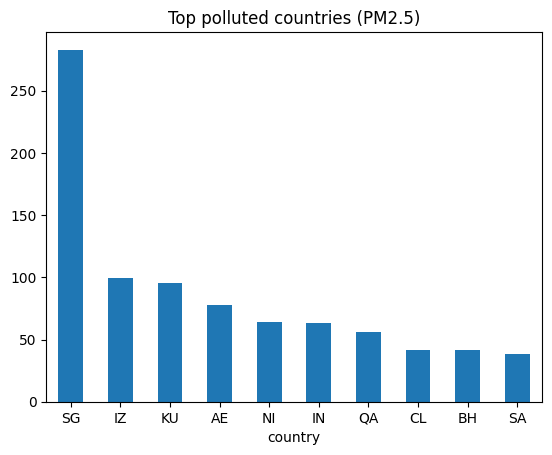

In [24]:
country_pollution.head(10).plot(kind='bar')
plt.title("Top polluted countries (PM2.5)")
plt.xticks(rotation=0)
plt.show()

### Year wise pollution

In [25]:
new_df['value'] = pd.to_numeric(new_df['value'], errors='coerce')  #numeric pollution value

In [26]:
yearly_pollution = new_df.groupby('year')['value'].mean().reset_index()

In [27]:
yearly_pollution

,year,value
0,2007,25.368333
1,2008,33.724000
2,2014,12.400000
3,2015,57.791000
4,2016,-3.201500
5,2017,26.663082
6,2018,28.046857
7,2019,17.278466
8,2020,-2.440090
9,2021,12.598407


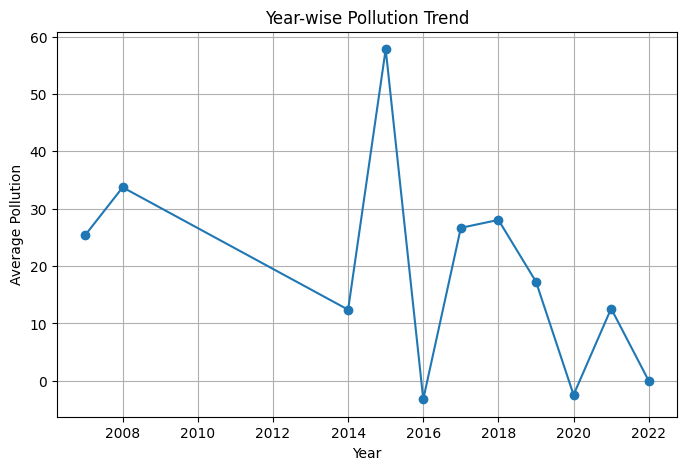

In [28]:
plt.figure(figsize=(8,5))
plt.plot(yearly_pollution['year'], yearly_pollution['value'], marker='o')
plt.title("Year-wise Pollution Trend")
plt.xlabel("Year")
plt.ylabel("Average Pollution")
plt.grid(True)
plt.show()

### Top cities

In [29]:
top_10_cities = df.groupby('location')['value'].mean().sort_values(ascending=False).head(10)

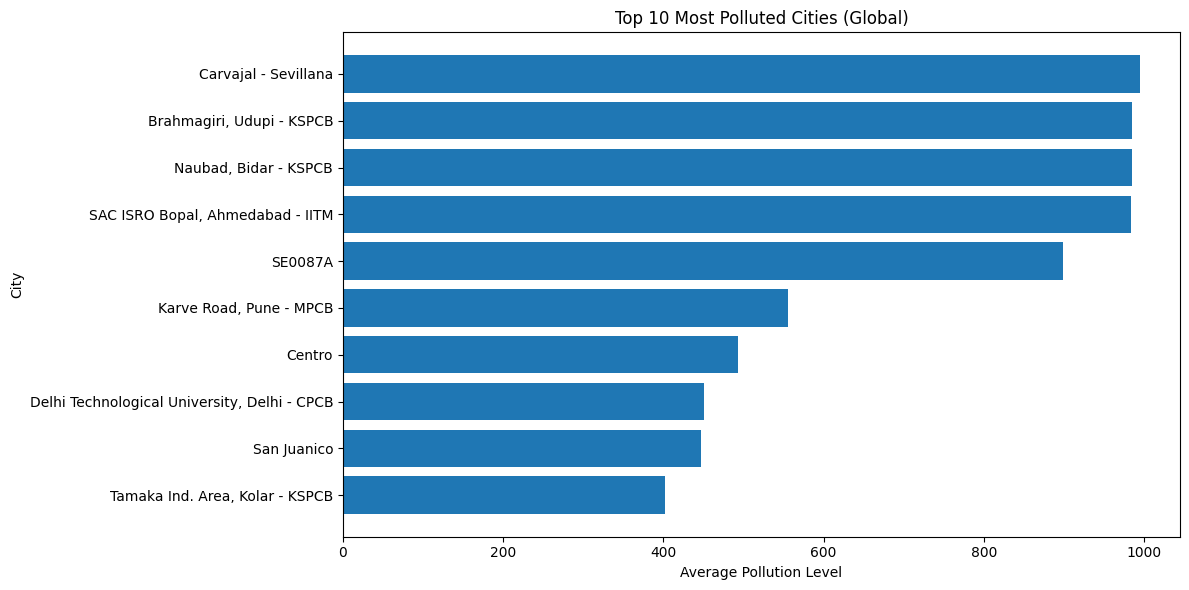

In [30]:
plt.figure(figsize=(12,6))
plt.barh(top_10_cities.index, top_10_cities.values)
plt.title("Top 10 Most Polluted Cities (Global)")
plt.xlabel("Average Pollution Level")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Monthly highest pollution

In [31]:
monthly_pollution = new_df.groupby('month')['value'].mean().reset_index()

In [32]:
print("Dataset start date:", df['timestamp'].min())
print("Dataset end date:", df['timestamp'].max())


Dataset start date: 2007-02-09 07:00:00+00:00
Dataset end date: 2022-05-26 18:00:00+00:00


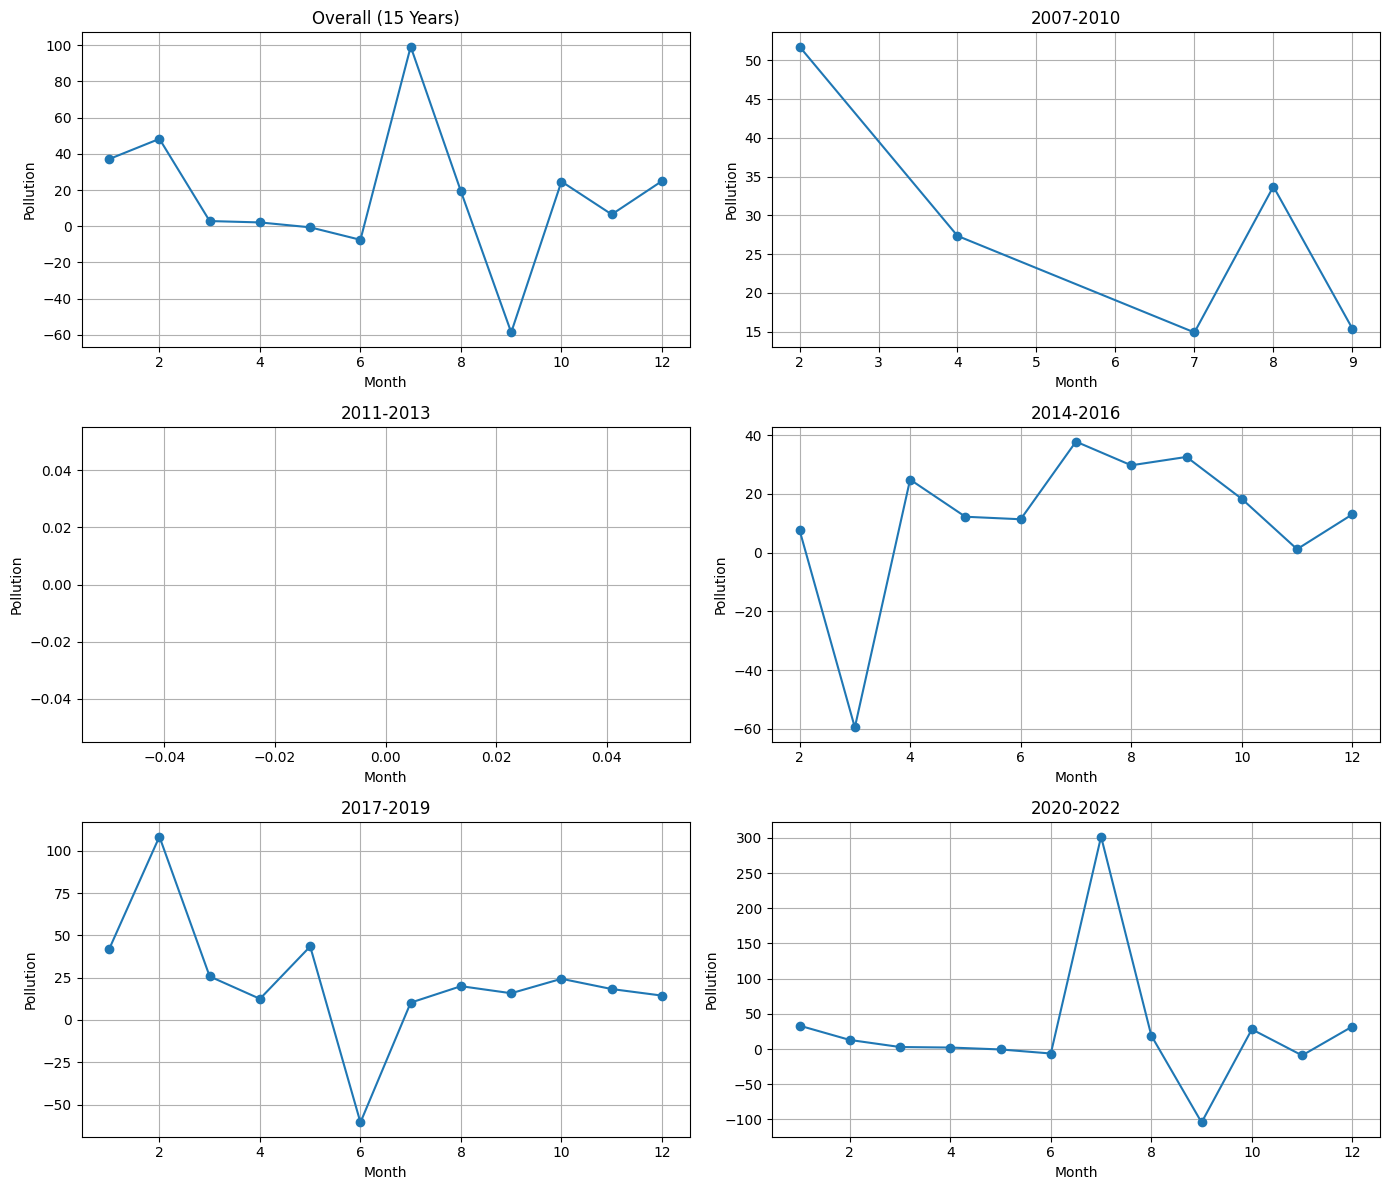

In [33]:
new_df['year'] = new_df['timestamp'].dt.year
new_df['month'] = new_df['timestamp'].dt.month

fig, axes = plt.subplots(3, 2, figsize=(14,12))

#Overall
overall = new_df.groupby('month')['value'].mean()
axes[0,0].plot(overall.index, overall.values, marker='o')
axes[0,0].set_title("Overall (15 Years)")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Pollution")
axes[0,0].grid(True)

# year Wise
year_groups = [
    (2007,2010),
    (2011,2013),
    (2014,2016),
    (2017,2019),
    (2020,2022)
]

positions = [(0,1),(1,0),(1,1),(2,0),(2,1)]

for (start,end), pos in zip(year_groups, positions):
    temp = new_df[(new_df['year']>=start) & (new_df['year']<=end)]
    monthly = temp.groupby('month')['value'].mean()
    
    ax = axes[pos]
    ax.plot(monthly.index, monthly.values, marker='o')
    ax.set_title(f"{start}-{end}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Pollution")
    ax.grid(True)

plt.tight_layout()
plt.show()


### Heatmap

In [34]:
num_df = new_df[['value','year','month','country','city']]

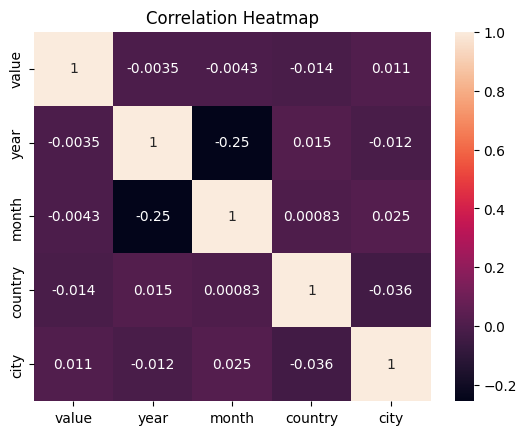

In [35]:
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Prepare ML data

In [124]:
ml_df = new_df.copy()

In [125]:
ml_df.shape

(1172530, 16)

In [126]:
ml_df['year'] = ml_df['timestamp'].dt.year
ml_df['month'] = ml_df['timestamp'].dt.month
ml_df['day'] = ml_df['timestamp'].dt.day

In [127]:
ml_df = ml_df[['country','city','year','month','day','value']]  # keep useful columns

In [132]:
ml_df.shape

(1172530, 6)

In [133]:
dup = ml_df.duplicated(subset=['country','city','year','month','day'], keep=False)

# see them (optional)
print(ml_df[dup].sort_values(['country','city','year','month','day']))

# remove duplicates → keep first correct entry
ml_df = ml_df.drop_duplicates(
    subset=['country','city','year','month','day'],
    keep='first'
)

print("Duplicates removed ✔")
print("New shape:", ml_df.shape)

         country  city  year  month  day   value
648541         0    35  2022      3   31 -999.00
752664         0    35  2022      3   31 -999.00
49297          0    35  2022      4   27   21.00
300446         0    35  2022      4   27   24.00
347040         0    35  2022      4   27   21.00
...          ...   ...   ...    ...  ...     ...
1049559       88  1921  2022      5   23   14.24
1199435       88  1921  2022      5   23    3.49
420406        88  1921  2022      5   24    3.49
449565        88  1921  2022      5   24    3.49
720950        88  1921  2022      5   24    3.49

[1147505 rows x 6 columns]
Duplicates removed ✔
New shape: (79199, 6)


In [134]:
ml_df.shape

(79199, 6)

count    79199.000000
mean        -1.885112
std        191.371644
min      -9999.000000
25%          4.000000
50%          8.000000
75%         16.599500
max      10000.000000
Name: value, dtype: float64


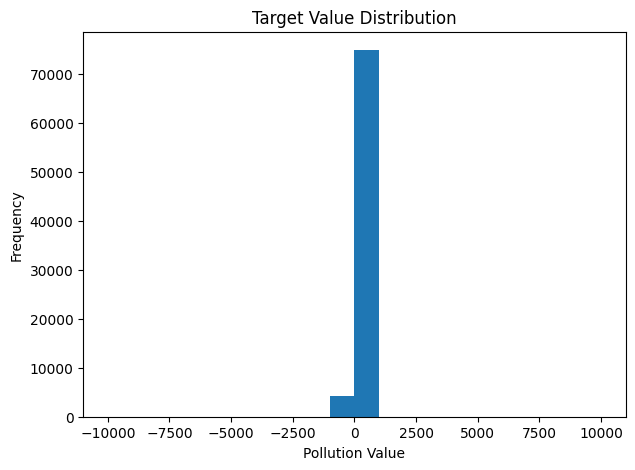


City distribution:
city
988     118
1439    116
585     115
1462    115
285     114
       ... 
125       1
331       1
1745      1
1117      1
1554      1
Name: count, Length: 2340, dtype: int64

Year distribution:
year
2007        4
2008        2
2014        4
2015       12
2016       87
2017      168
2018      240
2019      230
2020     1702
2021      764
2022    75986
Name: count, dtype: int64


In [135]:
# check distribution of target variable (pollution value)
print(ml_df['value'].describe())

plt.figure(figsize=(7,5))
plt.hist(ml_df['value'], bins=20)
plt.title("Target Value Distribution")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


# check city distribution (feature balance)
print("\nCity distribution:")
print(ml_df['city'].value_counts())

# check year distribution
print("\nYear distribution:")
print(ml_df['year'].value_counts().sort_index())


In [140]:
ml_df['value'] = ml_df['value'].apply(lambda x: 500 if x > 500 else x)

In [141]:
ml_df = ml_df[(ml_df['value'] >= 0)]


Skewness: 7.471685156849733


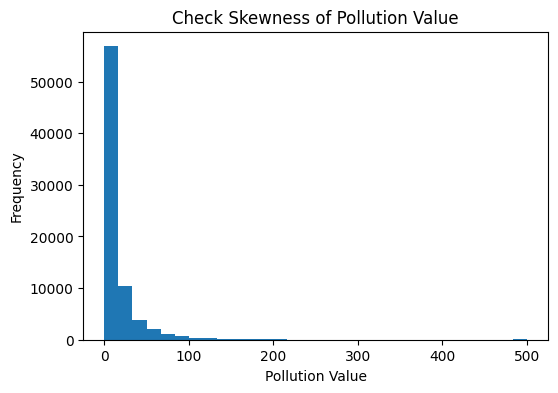

In [142]:
# check skewness of pollution value
print("Skewness:", ml_df['value'].skew())

# visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(ml_df['value'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


In [143]:
ml_df.shape

(76579, 6)

count    76579.000000
mean        17.247052
std         31.663445
min          0.000000
25%          4.133090
50%          8.000000
75%         17.000000
max        500.000000
Name: value, dtype: float64
value
0.000000      1271
0.010000         1
0.013589         1
0.018467         1
0.020000         1
              ... 
468.990000       1
474.000000       1
477.400000       1
494.000000       1
500.000000      92
Name: count, Length: 13256, dtype: int64


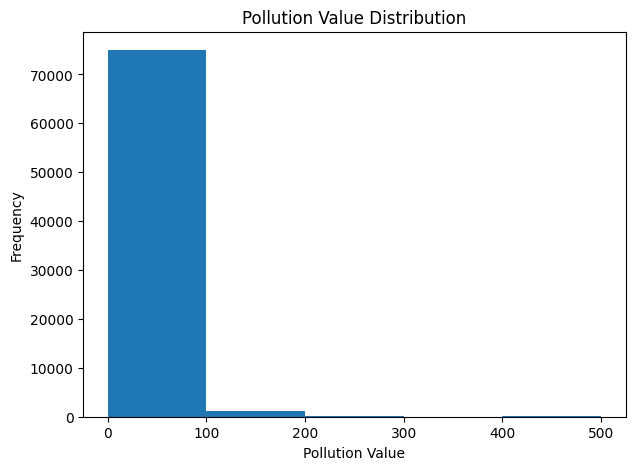

In [146]:
# value distribution statistics
print(ml_df['value'].describe())

# frequency distribution
print(ml_df['value'].value_counts().sort_index())

# histogram plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(ml_df['value'], bins=5)
plt.title("Pollution Value Distribution")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


In [147]:
ml_df.shape

(76579, 6)

In [148]:
draft_df=ml_df.copy()

In [149]:
draft_df.shape

(76579, 6)

## Binning


In [86]:
# create pollution category
bins = [0,50,100,200,300,500]
labels = ['Good','Moderate','Unhealthy','Very_Unhealthy','Hazard']

ml_df['pollution_cat'] = pd.cut(ml_df['value'], bins=bins, labels=labels, include_lowest=True)

# check count
print(ml_df['pollution_cat'].value_counts())

# balance dataset (take equal from each)
balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)

print(balanced_df['pollution_cat'].value_counts())


pollution_cat
Good              71155
Moderate           3847
Unhealthy          1259
Very_Unhealthy      164
Hazard              154
Name: count, dtype: int64
pollution_cat
Good              15000
Moderate          15000
Unhealthy         15000
Very_Unhealthy    15000
Hazard            15000
Name: count, dtype: int64


C:\Users\sahas\AppData\Local\Temp\ipykernel_21328\720563275.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)
C:\Users\sahas\AppData\Local\Temp\ipykernel_21328\720563275.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)


In [87]:
balanced_df.shape

(75000, 7)

In [88]:
balanced_df.columns

Index(['country', 'city', 'year', 'month', 'day', 'value', 'pollution_cat'], dtype='object')

In [89]:
balanced_df = balanced_df.drop('pollution_cat', axis=1)

Skewness: 0.8488821560858595


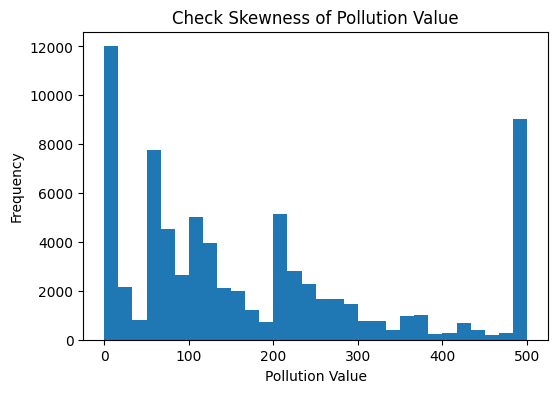

In [90]:
# check skewness of pollution value
print("Skewness:", balanced_df['value'].skew())

plt.figure(figsize=(6,4))
plt.hist(balanced_df['value'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()

In [91]:
y = balanced_df['value']  # target variable (pollution value)

In [92]:
X = balanced_df.drop('value', axis=1) # features

In [93]:
# ml_df.to_csv("Cleaned_AQ_ml.csv",index=False)

In [94]:
balanced_df.shape

(75000, 6)

In [95]:
X.shape

(75000, 5)

In [96]:
y.shape

(75000,)

### Train Test split

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

In [98]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 5)
Test shape: (15000, 5)


In [99]:
X_train.values

array([[  40, 1101, 2022,    4,   28],
       [  40,  808, 2022,    4,   25],
       [  40,  206, 2022,    5,   17],
       ...,
       [  10, 1094, 2022,    3,    9],
       [  29, 1902, 2022,    4,   20],
       [  40,  868, 2022,    4,   13]], shape=(60000, 5))

In [100]:
X_train.value_counts()

country  city  year  month  day
47       916   2022  5      6      105
40       210   2021  7      19     105
         716   2022  5      8       97
67       1336  2022  3      30      97
40       1088  2022  4      1       96
                                  ... 
88       1921  2022  4      27       1
                            29       1
                     5      1        1
                            4        1
         1862  2022  4      26       1
Name: count, Length: 16309, dtype: int64

In [101]:
y_train.values

array([270.  , 119.5 , 243.65, ..., 185.  ,   8.  ,  55.  ],
      shape=(60000,))

In [102]:
y_train.value_counts()

value
500.000000    7108
5.000000       374
4.000000       357
202.000000     347
6.000000       333
              ... 
6.349200         1
20.175000        1
26.629000        1
2.166667         1
10.228500        1
Name: count, Length: 4495, dtype: int64

In [103]:
X_test.values

array([[  40,  206, 2022,    4,   27],
       [  40,  867, 2022,    4,   14],
       [  14,  940, 2022,    5,   14],
       ...,
       [  40, 1739, 2022,    5,   16],
       [  84,   54, 2022,    4,   21],
       [  40,  207, 2022,    4,   18]], shape=(15000, 5))

In [104]:
y_test.values

array([224.37, 238.  ,  59.  , ...,  46.  ,   2.5 , 211.6 ],
      shape=(15000,))

## Linear Regression (sklearn inbuilt)

In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [106]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
y_pred_1= model.predict(X_test)

# evaluation
print("R2 Score:", r2_score(y_test, y_pred_1))
print("MAE:", mean_absolute_error(y_test, y_pred_1))
print("RMSE:", mean_squared_error(y_test, y_pred_1)**0.5)

R2 Score: 0.03267228873490147
MAE: 127.56690303148011
RMSE: 156.49263274722688


## OLS Regression (statsmodels)

In [108]:
# -------- OLS Regression (statsmodels) --------

import statsmodels.api as sm

# convert categorical columns to dummy variables
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test, drop_first=True)

# align test columns with train columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# add constant (intercept)
X_train_enc = sm.add_constant(X_train_enc)
X_test_enc  = sm.add_constant(X_test_enc)

# build OLS model
model = sm.OLS(y_train, X_train_enc).fit()

# model summary
print(model.summary())

# predictions
y_pred_2 = model.predict(X_test_enc)

# evaluation


print("MAE:", mean_absolute_error(y_test, y_pred_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_2)))
print("R2 Score:", r2_score(y_test, y_pred_2))


                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     527.8
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:27:51   Log-Likelihood:            -3.8782e+05
No. Observations:               60000   AIC:                         7.757e+05
Df Residuals:                   59994   BIC:                         7.757e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.521e+04   1759.658     14.328      0.0

## Gradient Descent Regression (sklearn SGD)

In [109]:
# -------- Gradient Descent Regression using SGD --------

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# categorical + numeric columns
cat_cols = ['country','city']
num_cols = ['year','month','day']

# preprocessing: encode categorical + scale numeric
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# SGD Regression model
model = SGDRegressor(max_iter=5000, learning_rate='constant', eta0=0.0001, random_state=25)

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# train
pipeline.fit(X_train, y_train)

# predict
y_pred = pipeline.predict(X_test)

# evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 7874.513483605645
RMSE: 88.73845549481716
R2 Score: 0.6889647819110788


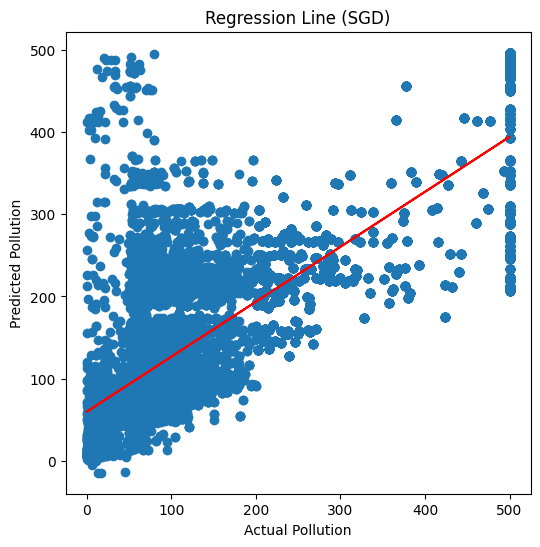

In [110]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

# regression line (red color)
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red')

plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Regression Line (SGD)")
plt.show()


# Linear Regression Model Train

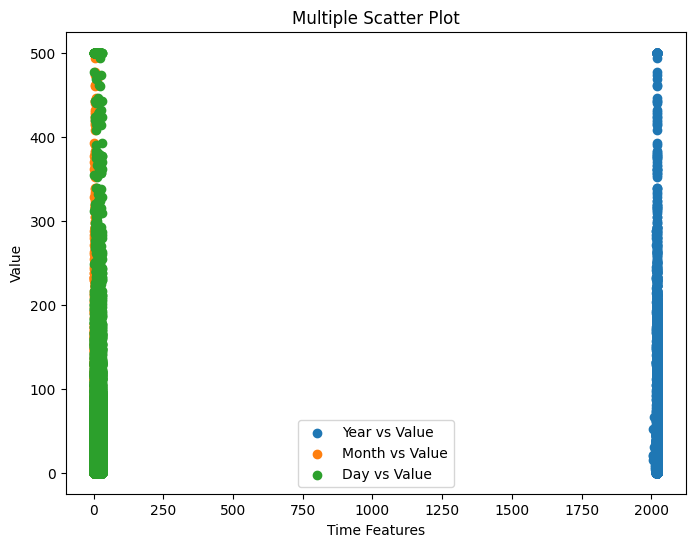

In [111]:
plt.figure(figsize=(8,6))

plt.scatter(ml_df['year'], ml_df['value'], label="Year vs Value")
plt.scatter(ml_df['month'], ml_df['value'], label="Month vs Value")
plt.scatter(ml_df['day'], ml_df['value'], label="Day vs Value")

plt.xlabel("Time Features")
plt.ylabel("Value")
plt.title("Multiple Scatter Plot")
plt.legend()

plt.show()


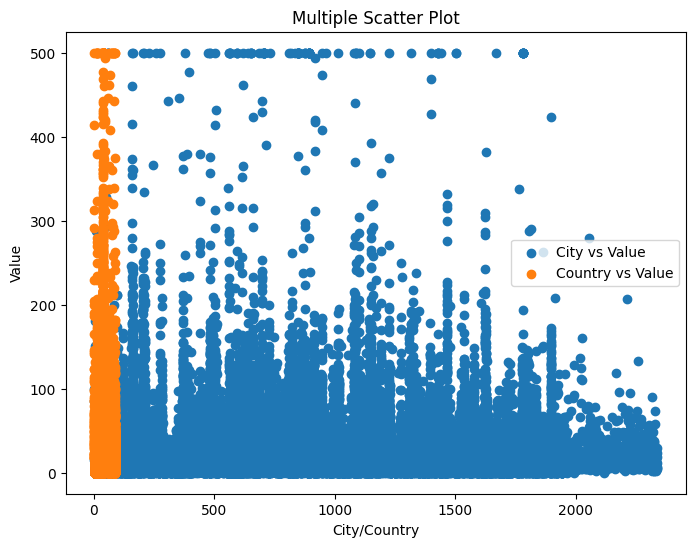

In [112]:
plt.figure(figsize=(8,6))

plt.scatter(ml_df['city'], ml_df['value'], label="City vs Value")
plt.scatter(ml_df['country'],ml_df['value'], label="Country vs Value")

plt.xlabel("City/Country")
plt.ylabel("Value")
plt.title("Multiple Scatter Plot")
plt.legend()

plt.show()


### using inbult function

In [113]:
# copy dataset
data = ml_df.copy()



In [114]:
# encode categorical columns
le_country = LabelEncoder()
le_city = LabelEncoder()

data['country'] = le_country.fit_transform(data['country'])
data['city'] = le_city.fit_transform(data['city'])



In [115]:
# features and target
X = data[['country','city','year','month','day']]
y = data['value']



In [116]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [117]:
X_train.value_counts()

country  city  year  month  day
88       1912  2022  5      24     1
0        35    2020  6      11     1
               2022  4      5      1
                            6      1
                            8      1
                                  ..
                            27     1
                            25     1
                            24     1
                            23     1
                            22     1
Name: count, Length: 61263, dtype: int64

In [118]:
# model
model = LinearRegression()
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
# prediction
y_pred = model.predict(X_test)

# evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)


R2 Score: 0.03359416596681519
MAE: 14.686376202142105
RMSE: 30.61289986904509


In [ ]:
new_df.to_csv("Cleaned_AQ.csv",index=False)

# Oversampling Data

In [230]:
draft_df.shape

(76579, 9)

In [231]:
# draft_df.to_csv("draft.csv",index=False)

In [232]:
draft_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76579 entries, 0 to 1199913
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        76579 non-null  int64  
 1   city           76579 non-null  int64  
 2   year           76579 non-null  int32  
 3   month          76579 non-null  int32  
 4   day            76579 non-null  int32  
 5   value          76579 non-null  float64
 6   country_enc    76579 non-null  int64  
 7   city_enc       76579 non-null  int64  
 8   pollution_bin  76579 non-null  int64  
dtypes: float64(1), int32(3), int64(5)
memory usage: 5.0 MB


In [233]:
# check range of value column
print("Min value:", draft_df['value'].min())
print("Max value:", draft_df['value'].max())


Min value: 0.0
Max value: 500.0


In [234]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# encode categorical
le1 = LabelEncoder()
le2 = LabelEncoder()

draft_df['country_enc'] = le1.fit_transform(draft_df['country'])
draft_df['city_enc'] = le2.fit_transform(draft_df['city'])

# make sure value in range
draft_df['value'] = draft_df['value'].clip(0,500)

# create bins
bins = [0,50,100,200,300,500]
draft_df['pollution_bin'] = pd.cut(draft_df['value'], bins=bins, labels=False, include_lowest=True)

# remove NaN bin rows (important)
draft_df = draft_df.dropna(subset=['pollution_bin'])

# convert to int
draft_df['pollution_bin'] = draft_df['pollution_bin'].astype(int)

# features & target
X = draft_df[['country_enc','city_enc','year','month','day']]
y = draft_df['pollution_bin']

# SMOTE oversampling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

oversampling_df = pd.DataFrame(X_res, columns=X.columns)
oversampling_df['pollution_bin'] = y_res

print("Original:", ml_df.shape)
print("After Oversampling:", oversampling_df.shape)
print(oversampling_df['pollution_bin'].value_counts())


Original: (76579, 6)
After Oversampling: (355775, 6)
pollution_bin
0    71155
1    71155
2    71155
4    71155
3    71155
Name: count, dtype: int64


In [235]:
oversampling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355775 entries, 0 to 355774
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   country_enc    355775 non-null  int64
 1   city_enc       355775 non-null  int64
 2   year           355775 non-null  int32
 3   month          355775 non-null  int32
 4   day            355775 non-null  int32
 5   pollution_bin  355775 non-null  int64
dtypes: int32(3), int64(3)
memory usage: 12.2 MB


In [238]:
oversampling_df.columns

Index(['country_enc', 'city_enc', 'year', 'month', 'day', 'pollution_bin'], dtype='object')

In [239]:
# check range of value column
print("Min value:", oversampling_df['pollution_bin'].min())
print("Max value:", oversampling_df['pollution_bin'].max())


Min value: 0
Max value: 4


In [240]:
ml_df.sample(10)

,country,city,year,month,day,value
1189251,84,72,2022,3,30,9.1000
292985,84,995,2022,5,19,12.5000
600209,46,220,2022,4,16,4.0000
255478,84,1096,2022,3,30,9.8000
234977,68,1931,2022,4,13,10.7108
257536,84,767,2022,4,4,3.9000
254109,84,644,2022,3,30,6.0000
37388,68,1615,2022,5,6,20.8400
100488,84,1373,2022,5,13,4.0000
8940,11,21,2022,4,2,3.3000


In [228]:
# check range of value column
print("Min value:", ml_df['value'].min())
print("Max value:", ml_df['value'].max())


Min value: 0.0
Max value: 500.0


In [185]:
oversampling_df.sample(10)

,country_enc,city_enc,year,month,day,value
226346,40,1459,2022,4,22,3
241466,49,883,2017,9,11,3
209215,67,942,2022,4,19,2
5535,25,1062,2022,4,14,0
269384,40,605,2022,4,18,3
315320,40,843,2022,4,28,4
142545,14,1303,2022,5,12,1
245291,40,212,2022,3,30,3
215846,40,160,2022,4,4,3
286907,38,638,2022,4,4,4


Skewness: 0.0


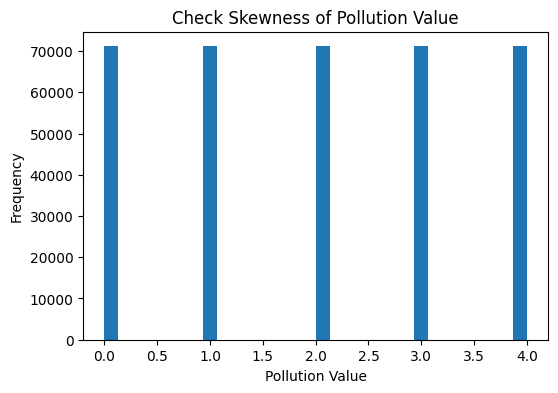

In [242]:
# check skewness of pollution value
print("Skewness:", oversampling_df['pollution_bin'].skew())

plt.figure(figsize=(6,4))
plt.hist(oversampling_df['pollution_bin'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()

In [244]:
y = oversampling_df['pollution_bin']  # target variable (pollution value)

In [245]:
X = oversampling_df.drop('pollution_bin', axis=1) # features

In [246]:
X.shape

(355775, 5)

In [247]:
y.shape

(355775,)

### Train Test  Split

In [248]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

In [249]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (284620, 5)
Test shape: (71155, 5)


In [250]:
X_train.values

array([[  40,  887, 2022,    5,   23],
       [  40,  160, 2022,    1,   31],
       [  88, 1124, 2022,    5,   15],
       ...,
       [  28,  770, 2022,    5,   23],
       [  79, 1616, 2022,    4,   10],
       [  84, 1488, 2022,    5,   14]], shape=(284620, 5))

In [251]:
X_train.value_counts()

country_enc  city_enc  year  month  day
40           160       2022  4      6      742
                                    5      594
             703       2022  5      23     532
                                    22     515
             160       2022  4      7      514
                                          ... 
88           1912      2022  4      27       1
                                    28       1
                                    29       1
                                    30       1
                             5      23       1
Name: count, Length: 88866, dtype: int64

In [252]:
X_train.columns

Index(['country_enc', 'city_enc', 'year', 'month', 'day'], dtype='object')

In [253]:
y_train.values

array([4, 3, 0, ..., 0, 1, 0], shape=(284620,))

In [254]:
y_train.value_counts()

pollution_bin
4    57150
0    57045
2    56870
1    56824
3    56731
Name: count, dtype: int64

In [255]:
X_test.values

array([[   2,  502, 2022,    4,    8],
       [  40,  481, 2022,    4,   16],
       [  82, 2310, 2020,    6,   11],
       ...,
       [  39,  371, 2022,    4,   17],
       [   4,  192, 2022,    4,    8],
       [  34,  493, 2022,    4,   20]], shape=(71155, 5))

In [256]:
y_test.values

array([4, 4, 0, ..., 3, 0, 3], shape=(71155,))

## Linear Regression (sklearn inbuilt)

In [257]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [258]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [259]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
y_pred_over_1= model.predict(X_test)

# evaluation
print("R2 Score:", r2_score(y_test, y_pred_over_1))
print("MAE:", mean_absolute_error(y_test, y_pred_over_1))
print("RMSE:", mean_squared_error(y_test,y_pred_over_1)**0.5)

R2 Score: 0.10052669315398144
MAE: 1.1252157922404165
RMSE: 1.3360771839032988


## OLS Regression (statsmodels)

In [260]:
# -------- OLS Regression (statsmodels) --------

import statsmodels.api as sm

# convert categorical columns to dummy variables
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test, drop_first=True)

# align test columns with train columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# add constant (intercept)
X_train_enc = sm.add_constant(X_train_enc)
X_test_enc  = sm.add_constant(X_test_enc)

# build OLS model
model = sm.OLS(y_train, X_train_enc).fit()

# model summary
print(model.summary())

# predictions
y_pred_over_2 = model.predict(X_test_enc)

# evaluation


print("MAE:", mean_absolute_error(y_test, y_pred_over_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_over_2)))
print("R2 Score:", r2_score(y_test, y_pred_over_2))


                            OLS Regression Results                            
Dep. Variable:          pollution_bin   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     6314.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:03:57   Log-Likelihood:            -4.8780e+05
No. Observations:              284620   AIC:                         9.756e+05
Df Residuals:                  284614   BIC:                         9.757e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         601.1836      7.043     85.364      

## Gradient Descent Regression (sklearn SGD)

In [261]:
oversampling_df.columns


Index(['country_enc', 'city_enc', 'year', 'month', 'day', 'pollution_bin'], dtype='object')

In [276]:
# -------- Gradient Descent Regression using SGD --------

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# categorical + numeric columns
cat_cols = ['country_enc','city_enc']
num_cols = ['year','month','day']

# preprocessing: encode categorical + scale numeric
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# SGD Regression model
model = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.0035, random_state=25)

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# train
pipeline.fit(X_train, y_train)

# predict
y_pred_over_3 = pipeline.predict(X_test)

# evaluation
print("MSE:", mean_squared_error(y_test, y_pred_over_3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_over_3)))
print("R2 Score:", r2_score(y_test, y_pred_over_3))

MSE: 0.6773432892821629
RMSE: 0.8230086811705956
R2 Score: 0.6587017851588892


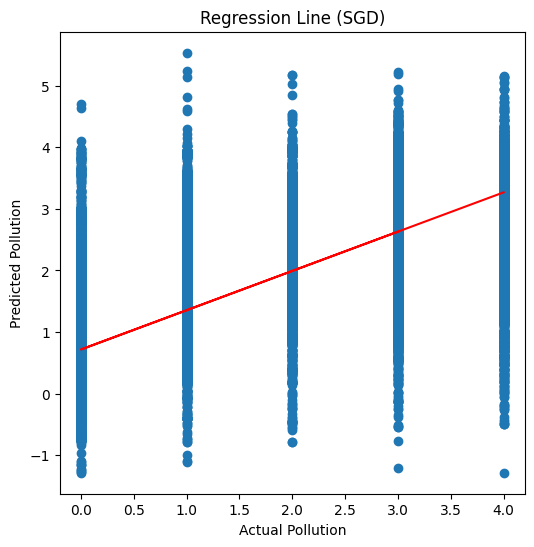

In [277]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_over_3)

# regression line (red color)
z = np.polyfit(y_test, y_pred_over_3, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red')

plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Regression Line (SGD)")
plt.show()


# Under Sampling

In [278]:
# -------- Under-sampling based on pollution bins --------

# create bins
bins = [0,50,100,200,300,500]
draft_df['pollution_bin'] = pd.cut(draft_df['value'], bins=bins, labels=False, include_lowest=True)

# remove NaN (if any)
draft_df = draft_df.dropna(subset=['pollution_bin'])
draft_df['pollution_bin'] = draft_df['pollution_bin'].astype(int)

# find minimum class count
min_count = draft_df['pollution_bin'].value_counts().min()

# under-sample each bin equally
undersampled_df = draft_df.groupby('pollution_bin').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)

print("Original shape:", draft_df.shape)
print("After Under-sampling:", undersampled_df.shape)
print(undersampled_df['pollution_bin'].value_counts())


Original shape: (76579, 9)
After Under-sampling: (770, 9)
pollution_bin
0    154
1    154
2    154
3    154
4    154
Name: count, dtype: int64


C:\Users\sahas\AppData\Local\Temp\ipykernel_21328\177236495.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = draft_df.groupby('pollution_bin').apply(


In [279]:
print("Min value:", draft_df['pollution_bin'].min())
print("Max value:", draft_df['pollution_bin'].max())

Min value: 0
Max value: 4
